# Data Science Capstone Project
## Exploratory Data Analysis - 2 Datasets

### Objective
In this project, I'll apply machine learning models to predict:
1. **FIFA Player Overall Rating** - Predict a player's overall rating based on their skills and attributes
2. **Credit Card Default** - Predict whether a client will default on their payment

Both datasets are clean with very few or no missing values in the columns that matter.

## Data Dictionary

**Dataset 1: FIFA Football Players Data**
- 17,954 players scraped from SoFIFA.com
- 51 columns: name, age, height, weight, nationality, position, overall rating, potential, value, wage, and 29 skill attributes
- 42 numerical, 9 categorical
- Target: `overall_rating` (continuous 47–94) — Regression problem
- Note: 4 national team columns are 95% missing and will be dropped. `release_clause_euro` is 10% missing.

**Dataset 2: Credit Card Default (UCI)**
- 30,000 Taiwan credit card clients
- 24 features: demographics, credit limit, payment history (PAY_0 to PAY_6), bill amounts, payment amounts
- Target: `default payment next month` (0 = no default, 1 = default)

loading imports and setting up visualization style

In [20]:
import subprocess
subprocess.run(['pip', 'install', 'xlrd'], capture_output=True)

FileNotFoundError: [Errno 2] No such file or directory: 'pip'

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# DATASET 1: FIFA FOOTBALL PLAYERS

loading the dataset

In [2]:
df_fifa = pd.read_csv('fifa_players.csv')
df_fifa.shape

(17954, 51)

In [3]:
df_fifa.head()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87


In [18]:
import subprocess
subprocess.run(['pip', 'install', 'xlrd'], capture_output=True)

FileNotFoundError: [Errno 2] No such file or directory: 'pip'

In [4]:
df_fifa.info()

<class 'pandas.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17954 non-null  str    
 1   full_name                      17954 non-null  str    
 2   birth_date                     17954 non-null  str    
 3   age                            17954 non-null  int64  
 4   height_cm                      17954 non-null  float64
 5   weight_kgs                     17954 non-null  float64
 6   positions                      17954 non-null  str    
 7   nationality                    17954 non-null  str    
 8   overall_rating                 17954 non-null  int64  
 9   potential                      17954 non-null  int64  
 10  value_euro                     17699 non-null  float64
 11  wage_euro                      17708 non-null  float64
 12  preferred_foot                 17954 non-null  str    
 1

In [5]:
df_fifa.describe().round(2)

,age,height_cm,weight_kgs,overall_rating,potential,value_euro,wage_euro,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
count,17954.00,17954.00,17954.00,17954.00,17954.00,1.769900e+04,17708.00,17954.00,17954.00,17954.00,...,17954.00,17954.00,17954.00,17954.00,17954.00,17954.00,17954.00,17954.00,17954.00,17954.00
mean,25.57,174.95,75.30,66.24,71.43,2.479280e+06,9902.13,1.11,2.95,2.36,...,46.85,55.82,46.66,49.86,53.41,48.36,58.68,47.16,47.73,45.71
std,4.71,14.03,7.08,6.96,6.13,5.687014e+06,21995.59,0.39,0.66,0.76,...,19.43,17.39,20.75,19.69,14.16,15.81,11.63,20.04,21.67,21.29
min,17.00,152.40,49.90,47.00,48.00,1.000000e+04,1000.00,1.00,1.00,1.00,...,3.00,11.00,3.00,2.00,10.00,5.00,12.00,3.00,2.00,3.00
25%,22.00,154.94,69.90,62.00,67.00,3.250000e+05,1000.00,1.00,3.00,2.00,...,32.00,44.00,26.00,38.00,44.00,38.00,51.00,30.00,27.00,24.00
50%,25.00,175.26,74.80,66.00,71.00,7.000000e+05,3000.00,1.00,3.00,2.00,...,51.00,59.00,52.00,55.00,55.00,49.00,60.00,52.50,55.00,52.00
75%,29.00,185.42,79.80,71.00,75.00,2.100000e+06,9000.00,1.00,3.00,3.00,...,62.00,69.00,64.00,64.00,64.00,60.00,67.00,64.00,66.00,64.00
max,46.00,205.74,110.20,94.00,95.00,1.105000e+08,565000.00,5.00,5.00,5.00,...,94.00,95.00,92.00,95.00,94.00,92.00,96.00,94.00,93.00,90.00


checking missing values across all 51 columns

In [6]:
missing_pct = (df_fifa.isnull().sum() / len(df_fifa) * 100).sort_values(ascending=False)

print(f'Total columns: {df_fifa.shape[1]}')
print(f'Columns with missing values: {(missing_pct > 0).sum()}')
print(f'Total missing values: {df_fifa.isnull().sum().sum():,}')
print()
print('Missing breakdown:')
print(missing_pct[missing_pct > 0].to_string())

Total columns: 51
Columns with missing values: 7
Total missing values: 70,726

Missing breakdown:
national_jersey_number    95.226690
national_team_position    95.226690
national_rating           95.226690
national_team             95.226690
release_clause_euro       10.231703
value_euro                 1.420296
wage_euro                  1.370168


the 4 national team columns are 95% missing - most players never play for their national team at this level. dropping those plus release_clause_euro (10% missing). the remaining columns are clean

In [7]:
cols_to_drop = ['national_team', 'national_team_position', 'national_rating', 'national_jersey_number', 'release_clause_euro']
df_fifa = df_fifa.drop(columns=cols_to_drop)

print(f'Dropped {len(cols_to_drop)} columns with high missing values')
print(f'New shape: {df_fifa.shape}')
print(f'Remaining missing values: {df_fifa.isnull().sum().sum():,}')

Dropped 5 columns with high missing values
New shape: (17954, 46)
Remaining missing values: 501


handle remaining missing values in value_euro and wage_euro by filling with median

In [8]:
df_fifa['value_euro'].fillna(df_fifa['value_euro'].median(), inplace=True)
df_fifa['wage_euro'].fillna(df_fifa['wage_euro'].median(), inplace=True)

print(f'Missing values after imputation: {df_fifa.isnull().sum().sum()}')

Missing values after imputation: 501


checking feature types

In [9]:
numerical_cols_fifa = df_fifa.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_fifa = df_fifa.select_dtypes(include=['object','string']).columns.tolist()

print(f'Numerical columns: {len(numerical_cols_fifa)}')
print(numerical_cols_fifa)
print()
print(f'Categorical columns: {len(categorical_cols_fifa)}')
print(categorical_cols_fifa)

Numerical columns: 39
['age', 'height_cm', 'weight_kgs', 'overall_rating', 'potential', 'value_euro', 'wage_euro', 'international_reputation(1-5)', 'weak_foot(1-5)', 'skill_moves(1-5)', 'crossing', 'finishing', 'heading_accuracy', 'short_passing', 'volleys', 'dribbling', 'curve', 'freekick_accuracy', 'long_passing', 'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots', 'aggression', 'interceptions', 'positioning', 'vision', 'penalties', 'composure', 'marking', 'standing_tackle', 'sliding_tackle']

Categorical columns: 7
['name', 'full_name', 'birth_date', 'positions', 'nationality', 'preferred_foot', 'body_type']


## FIFA - Problem Statement & Target Variable

**Problem:** Predict a FIFA player's overall rating based on their physical attributes, skill stats, and market value. Football clubs and analysts need accurate player ratings to guide scouting decisions, transfer negotiations, and squad planning.

**Target:** `overall_rating` - continuous variable (47–94), Regression problem

checking target distribution

In [10]:
print('Target: overall_rating')
print(df_fifa['overall_rating'].describe())
print()
print('Is continuous? YES')
print(f'Range: {df_fifa["overall_rating"].min()} to {df_fifa["overall_rating"].max()}')
print(f'Mean: {df_fifa["overall_rating"].mean():.2f}')
print(f'Std: {df_fifa["overall_rating"].std():.2f}')

Target: overall_rating
count    17954.000000
mean        66.240169
std          6.963730
min         47.000000
25%         62.000000
50%         66.000000
75%         71.000000
max         94.000000
Name: overall_rating, dtype: float64

Is continuous? YES
Range: 47 to 94
Mean: 66.24
Std: 6.96


visualizing the target distribution

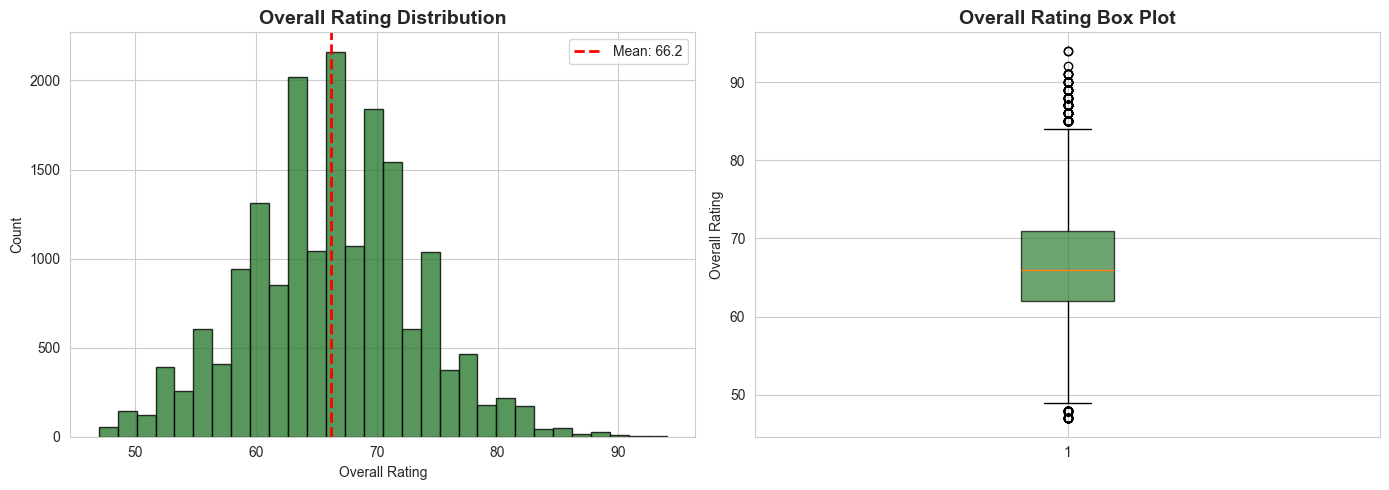

right-skewed slightly - most players rated 60-75, very few elite (85+)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_fifa['overall_rating'], bins=30, color='#2E7D32', edgecolor='black', alpha=0.8)
axes[0].axvline(df_fifa['overall_rating'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_fifa["overall_rating"].mean():.1f}')
axes[0].set_title('Overall Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Overall Rating')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(df_fifa['overall_rating'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2E7D32', alpha=0.7))
axes[1].set_title('Overall Rating Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Overall Rating')

plt.tight_layout()
plt.show()

print('right-skewed slightly - most players rated 60-75, very few elite (85+)')

checking which features correlate most strongly with overall_rating

Top 10 features most correlated with overall_rating:
reactions                        0.856
composure                        0.729
potential                        0.647
value_euro                       0.631
wage_euro                        0.577
short_passing                    0.507
vision                           0.507
long_passing                     0.490
international_reputation(1-5)    0.489
ball_control                     0.464

Bottom 5 (least correlated):
weak_foot(1-5)    0.216
acceleration      0.205
weight_kgs        0.151
balance           0.115
height_cm         0.038


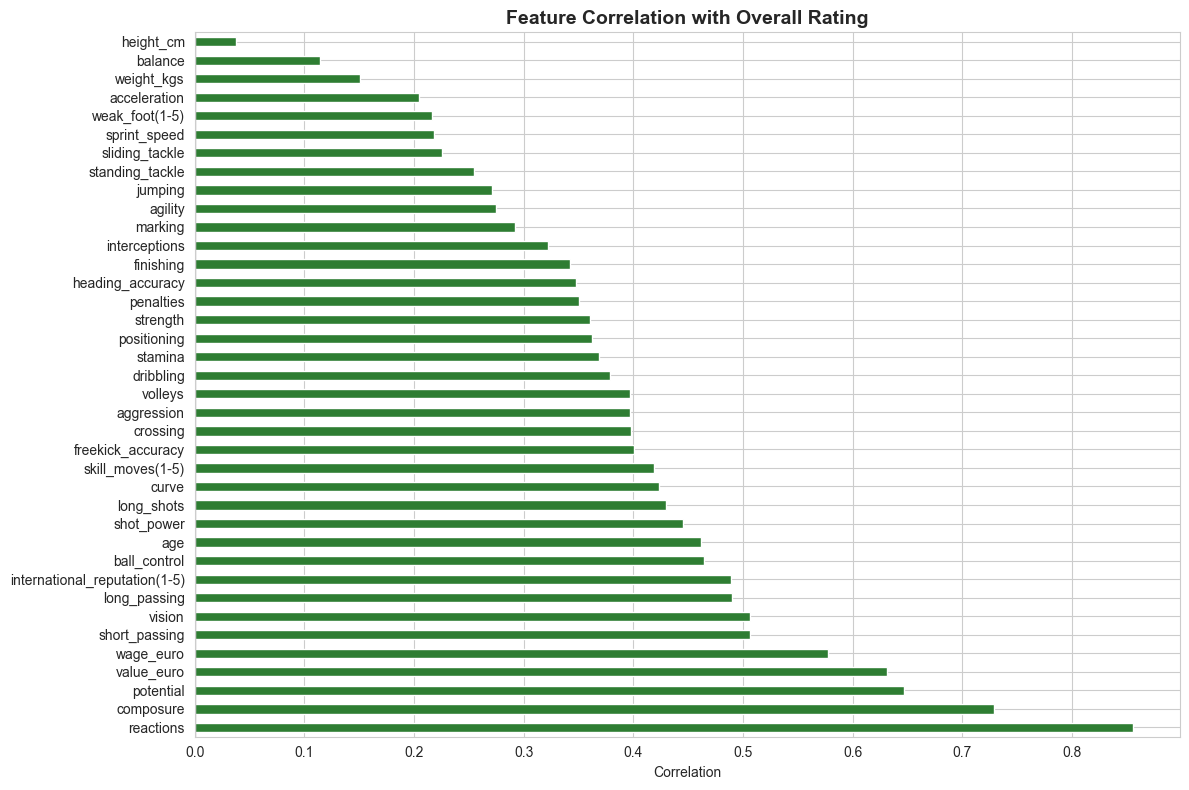

In [12]:
corr = df_fifa[numerical_cols_fifa].corr()['overall_rating'].drop('overall_rating').sort_values(ascending=False)

print('Top 10 features most correlated with overall_rating:')
print(corr.head(10).round(3).to_string())
print()
print('Bottom 5 (least correlated):')
print(corr.tail(5).round(3).to_string())

plt.figure(figsize=(12, 8))
corr.plot(kind='barh', color=['#2E7D32' if v > 0 else '#D32F2F' for v in corr])
plt.title('Feature Correlation with Overall Rating', fontsize=14, fontweight='bold')
plt.xlabel('Correlation')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

checking outliers in key numerical columns

In [13]:
outlier_summary = []

for col in numerical_cols_fifa:
    Q1 = df_fifa[col].quantile(0.25)
    Q3 = df_fifa[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_fifa[col] < lower) | (df_fifa[col] > upper)).sum()
    if n_out > 0:
        outlier_summary.append({'Column': col, 'Count': int(n_out), 'Pct': f'{n_out/len(df_fifa)*100:.2f}%'})

print(pd.DataFrame(outlier_summary).to_string())
print('\noutliers in value/wage represent elite players (Messi, Ronaldo etc.) - real data, not errors. will keep them')

                           Column  Count     Pct
0                             age     30   0.17%
1                      weight_kgs    117   0.65%
2                  overall_rating    162   0.90%
3                       potential    163   0.91%
4                      value_euro   2419  13.47%
5                       wage_euro   2001  11.15%
6   international_reputation(1-5)   1584   8.82%
7                  weak_foot(1-5)   6761  37.66%
8                skill_moves(1-5)     52   0.29%
9                heading_accuracy   1038   5.78%
10                  short_passing   1563   8.71%
11                      dribbling   1963  10.93%
12                   long_passing     17   0.09%
13                   ball_control   2073  11.55%
14                   acceleration    509   2.84%
15                   sprint_speed    734   4.09%
16                        agility    207   1.15%
17                      reactions    133   0.74%
18                        balance    246   1.37%
19                  

# DATASET 2: CREDIT CARD DEFAULT

loading the credit card dataset - header=1 because the first row has generic X1, X2... labels

In [14]:
df_cc = pd.read_excel('default of credit card clients.xls', header=1)
df_cc.shape

ImportError: `Import xlrd` failed. Install xlrd >= 2.0.1 for xls Excel support Use pip or conda to install the xlrd package.

In [15]:
df_cc.head()

NameError: name 'df_cc' is not defined

In [16]:
df_cc.info()

NameError: name 'df_cc' is not defined

In [17]:
df_cc.describe().round(2)

NameError: name 'df_cc' is not defined

checking feature types

In [18]:
numerical_cols_cc = df_cc.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_cc = df_cc.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical columns: {len(numerical_cols_cc)}')
print(f'Categorical columns: {len(categorical_cols_cc)}')

Numerical columns: 25
Categorical columns: 0


check for missing values

In [19]:
print(f'Total missing values: {df_cc.isnull().sum().sum()}')
print('Data completeness: 100%')

Total missing values: 0
Data completeness: 100%


## Credit Card - Problem Statement & Target Variable

**Problem:** Predict credit card default based on demographics, credit limit, and payment history. Financial institutions need to identify high-risk clients early to manage portfolio risk and reduce losses.

**Target:** `default payment next month` - Binary Classification (0 = no default, 1 = default)

In [20]:
target_col_cc = 'default payment next month'

print('Target distribution:')
print(df_cc[target_col_cc].value_counts())
print()
print('Percentage:')
print(df_cc[target_col_cc].value_counts(normalize=True).round(3) * 100)

if df_cc[target_col_cc].value_counts(normalize=True).max() > 0.7:
    print('\nclass imbalance detected - will handle with SMOTE or class weights')

Target distribution:
default payment next month
0    23364
1     6636
Name: count, dtype: int64

Percentage:
default payment next month
0    77.9
1    22.1
Name: proportion, dtype: float64

class imbalance detected - will handle with SMOTE or class weights


visualizing the target

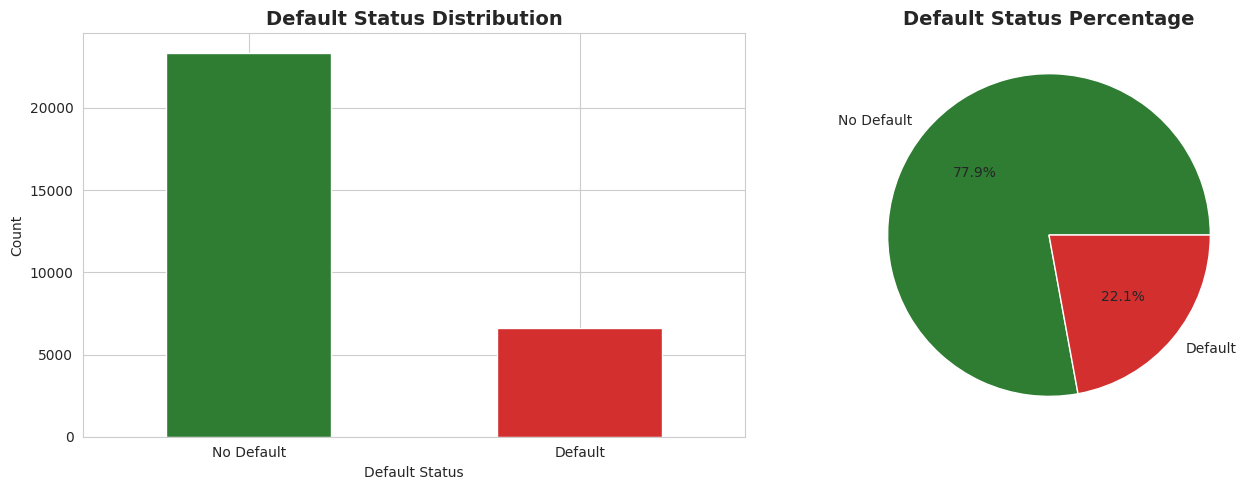

clear class imbalance - 77.9% no default vs 22.1% default


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_cc[target_col_cc].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2E7D32', '#D32F2F']
)
axes[0].set_title('Default Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Default Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_xticklabels(['No Default', 'Default'])

df_cc[target_col_cc].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#2E7D32', '#D32F2F'], labels=['No Default', 'Default']
)
axes[1].set_title('Default Status Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('clear class imbalance - 77.9% no default vs 22.1% default')

checking outliers

In [22]:
outlier_summary_cc = []

for col in numerical_cols_cc[:10]:
    Q1 = df_cc[col].quantile(0.25)
    Q3 = df_cc[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_cc[col] < lower) | (df_cc[col] > upper)).sum()
    if n_out > 0:
        outlier_summary_cc.append({'Column': col, 'Count': int(n_out), 'Pct': f'{n_out/len(df_cc)*100:.2f}%'})

if outlier_summary_cc:
    print(pd.DataFrame(outlier_summary_cc).to_string())
    print('\nmostly in credit limit and bill amounts - expected given the wide range of client profiles')
else:
    print('no major outliers detected')

      Column  Count     Pct
0  LIMIT_BAL    167   0.56%
1  EDUCATION    454   1.51%
2        AGE    272   0.91%
3      PAY_0   3130  10.43%
4      PAY_2   4410  14.70%
5      PAY_3   4209  14.03%
6      PAY_4   3508  11.69%

mostly in credit limit and bill amounts - expected given the wide range of client profiles


## Final Summary

In [23]:
print('='*80)
print('CAPSTONE PROJECT SUMMARY')
print('='*80)

print('\nDATASET 1: FIFA FOOTBALL PLAYERS')
print(f'  Rows: {df_fifa.shape[0]:,} | Columns: {df_fifa.shape[1]}')
print(f'  Numerical: {len(numerical_cols_fifa)} | Categorical: {len(categorical_cols_fifa)}')
print(f'  Missing Values after cleaning: 0')
print(f'  Problem: Regression (Predict overall_rating)')
print(f'  Target Range: {df_fifa["overall_rating"].min()} to {df_fifa["overall_rating"].max()} | Mean: {df_fifa["overall_rating"].mean():.1f}')

print('\nDATASET 2: CREDIT CARD DEFAULT')
print(f'  Rows: {df_cc.shape[0]:,} | Columns: {df_cc.shape[1]}')
print(f'  Numerical: {len(numerical_cols_cc)} | Categorical: {len(categorical_cols_cc)}')
print(f'  Missing Values: 0')
print(f'  Problem: Binary Classification (Default vs No Default)')
print(f'  Target: No Default=77.9%, Default=22.1%')

print('\nREADY FOR MODELING')
print('='*80)

CAPSTONE PROJECT SUMMARY

DATASET 1: FIFA FOOTBALL PLAYERS
  Rows: 17,954 | Columns: 46
  Numerical: 39 | Categorical: 7
  Missing Values after cleaning: 0
  Problem: Regression (Predict overall_rating)
  Target Range: 47 to 94 | Mean: 66.2

DATASET 2: CREDIT CARD DEFAULT
  Rows: 30,000 | Columns: 25
  Numerical: 25 | Categorical: 0
  Missing Values: 0
  Problem: Binary Classification (Default vs No Default)
  Target: No Default=77.9%, Default=22.1%

READY FOR MODELING
